In [1]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


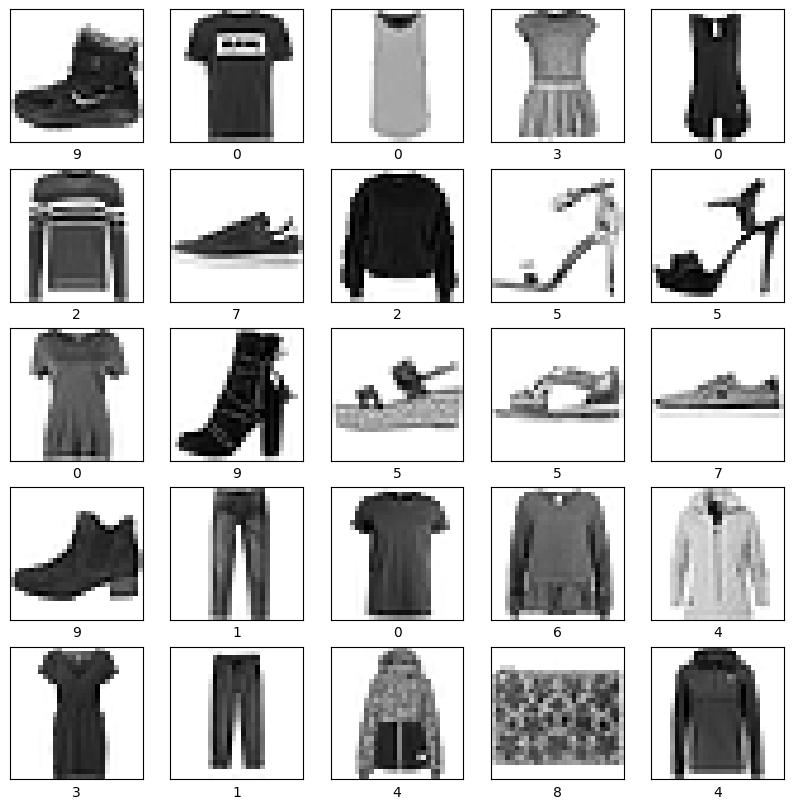

In [3]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

## Preprocessing data for CNN

In [5]:
# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

X_train_cnn = X_train_norm[..., np.newaxis]  # add channel dimension → (60000, 28, 28, 1)
X_test_cnn = X_test_norm[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train_cnn.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


## Building the CNN model

In [7]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

In [8]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                  # image data with spatial structure
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8539 - loss: 0.4144 - val_accuracy: 0.8843 - val_loss: 0.3246
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8983 - loss: 0.2845 - val_accuracy: 0.8975 - val_loss: 0.2839
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9129 - loss: 0.2405 - val_accuracy: 0.9072 - val_loss: 0.2494
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9232 - loss: 0.2105 - val_accuracy: 0.9123 - val_loss: 0.2471
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9318 - loss: 0.1853 - val_accuracy: 0.9148 - val_loss: 0.2391


## Evaluate the CNN model

In [9]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9098 - loss: 0.2527
CNN Test Accuracy: 0.9097999930381775


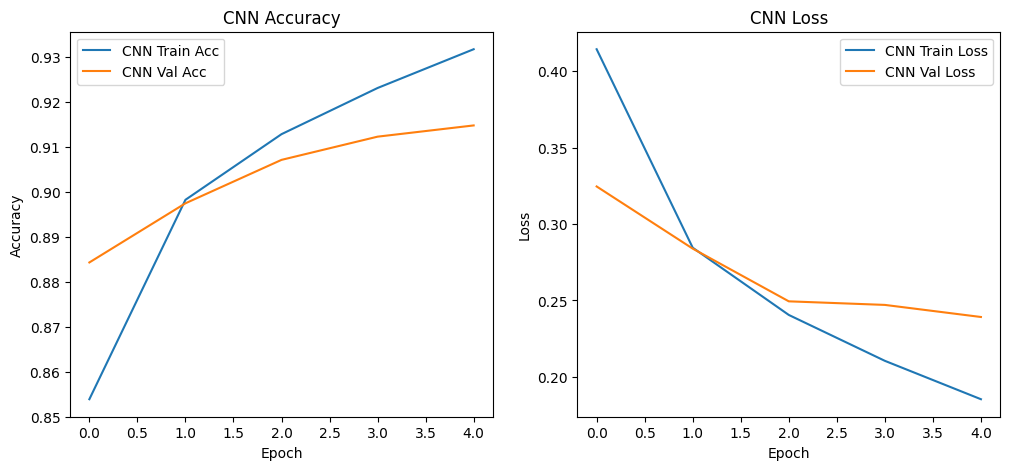

In [10]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


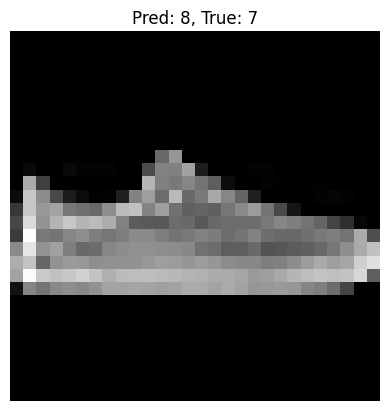

In [11]:
# Get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

# Find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])  # predicted class

    if pred != y_test[i]:                 # compare to true label
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

## Model performance on rotated images

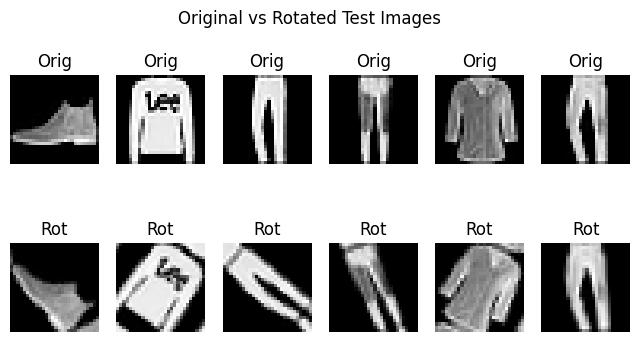

In [12]:
# Visualize rotated test images (to see what changed)

rotation_layer_eval = tf.keras.layers.RandomRotation(0.15)

X_test_rot_eval_cnn = rotation_layer_eval(X_test_cnn, training=True)

plt.figure(figsize=(8, 4))

for i in range(6):
    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Orig")
    plt.axis('off')

    # Rotated
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_test_rot_eval_cnn[i].numpy().squeeze(), cmap='gray')
    plt.title("Rot")
    plt.axis('off')

plt.suptitle("Original vs Rotated Test Images")
plt.show()

In [13]:
# Evaluate original models on rotated data

cnn_rot_eval_loss, cnn_rot_eval_acc = cnn_model.evaluate(X_test_rot_eval_cnn, y_test)

print("CNN accuracy (original test):", cnn_acc)
print("CNN accuracy (rotated test):", cnn_rot_eval_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4330 - loss: 2.9614
CNN accuracy (original test): 0.9097999930381775
CNN accuracy (rotated test): 0.43299999833106995


In [14]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

In [15]:
# Define the CNN model for rotated data
cnn_model_rot = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

# Compile the CNN model
cnn_model_rot.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# Train the CNN model using rotated training data
cnn_history_rot = cnn_model_rot.fit(
    X_train_rot_train_cnn,                        # rotated training images for CNN
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)

# Evaluate the CNN model on rotated test data
cnn_loss_rot, cnn_acc_rot = cnn_model_rot.evaluate(X_test_rot_train_cnn, y_test)  # evaluate on unseen rotated test data
print("CNN (Rotated) Test Accuracy:", cnn_acc_rot)                                 # report final test accuracy

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7527 - loss: 0.6903 - val_accuracy: 0.7862 - val_loss: 0.6033
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8214 - loss: 0.4946 - val_accuracy: 0.8242 - val_loss: 0.4938
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8469 - loss: 0.4278 - val_accuracy: 0.8330 - val_loss: 0.4584
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8608 - loss: 0.3836 - val_accuracy: 0.8347 - val_loss: 0.4485
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8727 - loss: 0.3468 - val_accuracy: 0.8367 - val_loss: 0.4609
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8344 - loss: 0.4711
CNN (Rotated) Test Accuracy: 0.8343999981880188


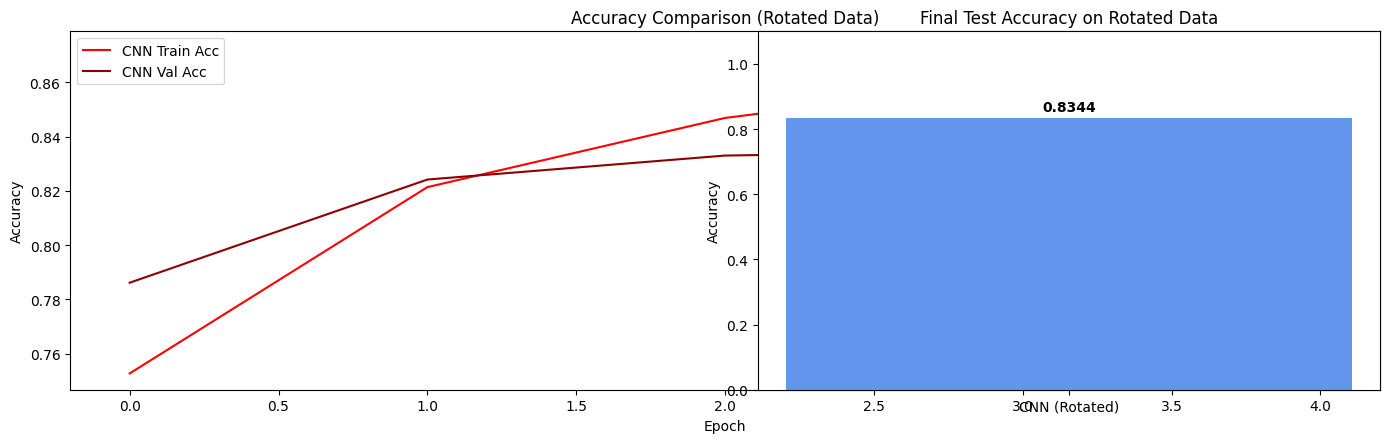

In [17]:
import matplotlib.pyplot as plt

# Create the visual comparison plots
plt.figure(figsize=(14, 5))

plt.plot(cnn_history_rot.history['accuracy'], label='CNN Train Acc', color='red')
plt.plot(cnn_history_rot.history['val_accuracy'], label='CNN Val Acc', color='darkred')

plt.title('Accuracy Comparison (Rotated Data)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Final Test Accuracy comparison
plt.subplot(1, 2, 2)
models = ['CNN (Rotated)']
accuracies = [cnn_acc_rot]
colors = ['cornflowerblue', 'lightcoral']
plt.bar(models, accuracies, color=colors, width=0.4)
plt.title('Final Test Accuracy on Rotated Data')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)

# Add value labels on top of the bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [18]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected and available for TensorFlow.")
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


In [ ]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # resize ALL images to 128x128 (so all same shape)
    batch_size=32                               # number of images per batch
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio as training set
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same resizing as training set
    batch_size=32                               # same batch size as training set
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Add channel dimension: (28,28) -> (28,28,1)
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

# Create training dataset
train_ds_raw = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_raw = train_ds_raw.batch(32)

# Create test dataset
test_ds_raw = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds_raw = test_ds_raw.batch(32)

# Class names
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# View labels from first batch
for images, labels in train_ds_raw.take(1):
    print(labels.numpy())
    print(class_names)

[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9 1 0 6 4 3 1 4 8 4 3 0 2 4 4 5 3]
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [24]:
train_ds_raw.class_names = class_names

print(train_ds_raw.class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


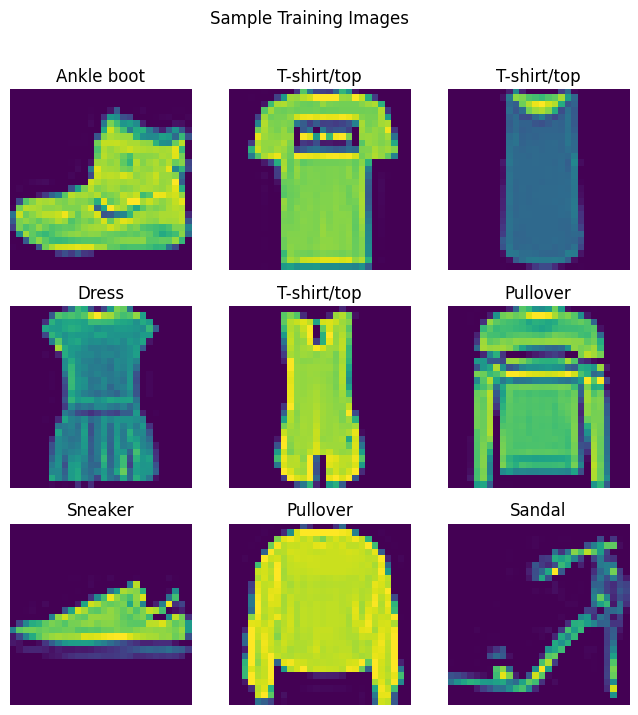

In [25]:
# View one batch of images
plt.figure(figsize=(8, 8))

for images, labels in train_ds_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # display 0–255 RGB correctly
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()

In [26]:
# Add channel dimension: (28, 28) -> (28, 28, 1)
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

train_ds_padded = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_padded = train_ds_padded.batch(32)

val_ds_padded = tf.data.Dataset.from_tensor_slices((X_test, y_test))
val_ds_padded = val_ds_padded.batch(32)

# Split validation into validation + test (50/50 split)
val_batches = tf.data.experimental.cardinality(val_ds_padded).numpy()

test_ds_padded = val_ds_padded.take(val_batches // 2)
val_ds_padded = val_ds_padded.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds_padded).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_padded).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_padded).numpy())

Train batches: 1875
Validation batches: 157
Test batches: 156


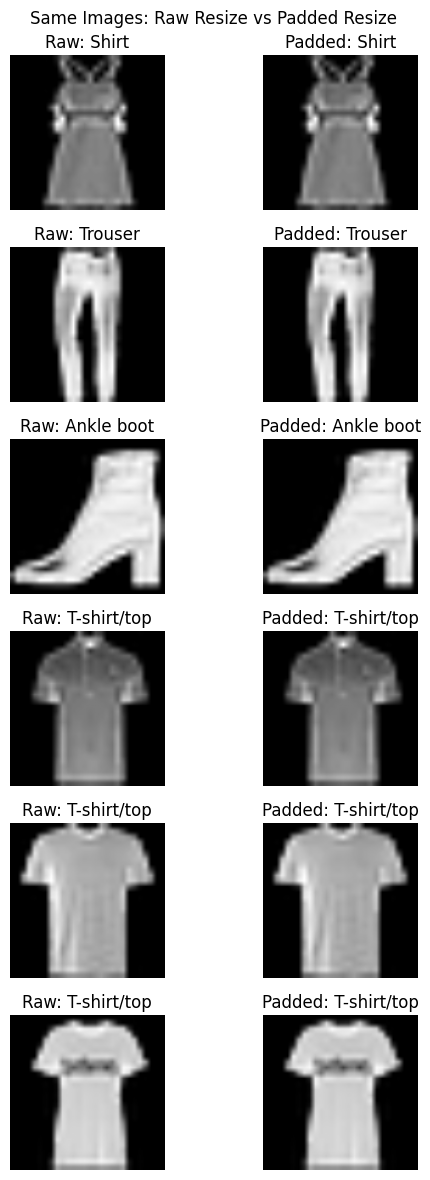

In [ ]:
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Class names
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

random.seed(42)

# 6 random images
indices = random.sample(range(len(X_train)), 6)

plt.figure(figsize=(6, 12))

for i, idx in enumerate(indices):

    img = X_train[idx]
    label = class_names[y_train[idx]]

    # Raw resize
    raw_img = tf.image.resize(img[..., tf.newaxis], (128, 128))

    # Padded resize
    padded_img = tf.image.resize_with_pad(img[..., tf.newaxis], 128, 128)

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(tf.squeeze(raw_img), cmap="gray")
    plt.title(f"Raw: {label}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(tf.squeeze(padded_img), cmap="gray")
    plt.title(f"Padded: {label}")
    plt.axis("off")

plt.suptitle("Same Images: Raw Resize vs Padded Resize")
plt.tight_layout()
plt.show()

In [29]:
# Normalize pixel values from 0–255 to 0–1 for all datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_padded = train_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # normalize images; keep labels unchanged
)

val_ds_padded = val_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to validation data
)

test_ds_padded = test_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to test data
)

# Shuffle only the training data to improve learning 
# Did above but best practice to do after all preprocessing steps
train_ds_padded = train_ds_padded.shuffle(
    1000,                                        # buffer size (>= dataset size for good mixing)
    seed=42                                      # ensures reproducible shuffling
)

In [30]:
# check normalization worked correctly (should be 0–1 range)
for images, labels in train_ds_padded.take(1):
    print(images.numpy().min(), images.numpy().max())

0.0 1.0


In [34]:
# set random seed for reproducibility
from tensorflow.keras import models, layers
tf.random.set_seed(42)

# define the CNN model
cnn_fashion = models.Sequential([
    layers.Input(shape=(28, 28, 1)),              # input: 28x28 grayscale image

    layers.Conv2D(32, (3, 3), activation="relu",
                  padding="same"),                # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                  # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu",
                  padding="same"),                # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                  # further reduce size

    layers.Flatten(),                             # convert feature maps to vector
    layers.Dense(64, activation="relu"),          # combine features
    layers.Dense(10, activation="softmax")        # 10 clothing categories
])

# Compile CNN model
cnn_fashion.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # multiclass classification loss
    metrics=["accuracy"]                          # track accuracy
)

# Train CNN model
cnn_history = cnn_fashion.fit(
    train_ds_padded,                              # training dataset
    validation_data=val_ds_padded,                # validation dataset
    epochs=10
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_fashion.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8461 - loss: 0.4313 - val_accuracy: 0.8774 - val_loss: 0.3307
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8968 - loss: 0.2840 - val_accuracy: 0.9006 - val_loss: 0.2680
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9143 - loss: 0.2361 - val_accuracy: 0.9050 - val_loss: 0.2462
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 128s 68ms/step - accuracy: 0.9232 - loss: 0.2061 - val_accuracy: 0.9073 - val_loss: 0.2435
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9330 - loss: 0.1792 - val_accuracy: 0.9213 - val_loss: 0.2206
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9405 - loss: 0.1579 - val_accuracy: 0.9205 - val_loss: 0.2239
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9486 - loss: 0.1394 - val_accuracy: 0.9235 - val_loss: 0.2278
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9551 

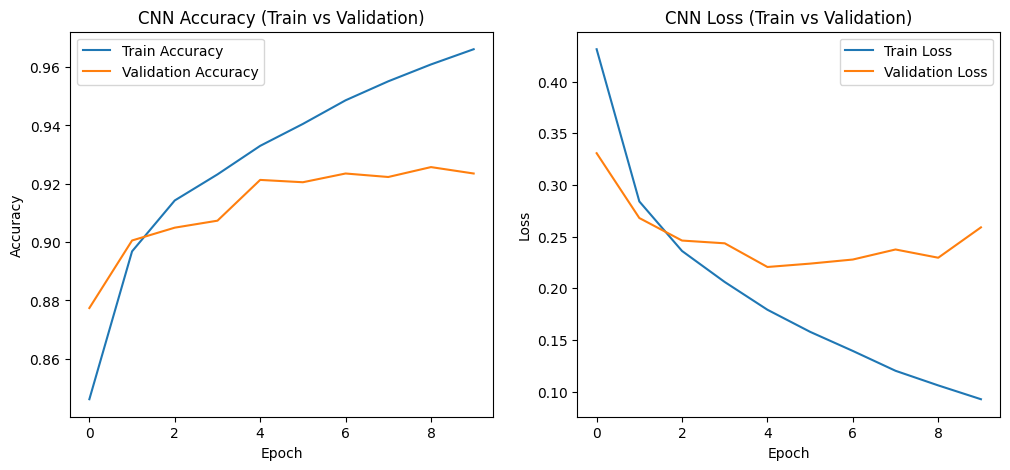

In [35]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

## Model 1

In [38]:
# add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_fashion = models.Sequential([
    layers.Input(shape=(28, 28, 1)),              # input: 28x28 grayscale image

    layers.Conv2D(32, (3, 3), activation="relu",
                  padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu",
                  padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")        # 10 Fashion MNIST classes
])

# Compile CNN model
cnn_fashion.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train CNN model
cnn_history = cnn_fashion.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=5,
    callbacks=[early_stopping]
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_fashion.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.8465 - loss: 0.4224 - val_accuracy: 0.8816 - val_loss: 0.3204
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9016 - loss: 0.2756 - val_accuracy: 0.8926 - val_loss: 0.2836
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9154 - loss: 0.2310 - val_accuracy: 0.9127 - val_loss: 0.2331
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9265 - loss: 0.2011 - val_accuracy: 0.9145 - val_loss: 0.2296
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9348 - loss: 0.1747 - val_accuracy: 0.9179 - val_loss: 0.2154
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9131 - loss: 0.2473
CNN test accuracy: 0.9131


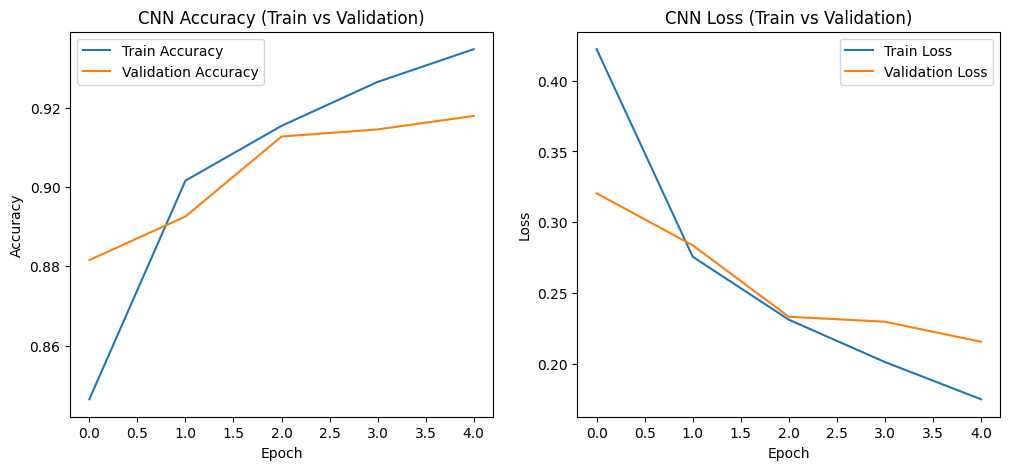

In [39]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

## Model 2

In [41]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
     layers.RandomRotation(0.05),
     layers.RandomZoom(0.05),
     layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_fashion = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    # Optional dropout
     layers.Dropout(0.2),

    layers.Dense(10, activation="softmax")       # 10 Fashion MNIST classes
])

# Compile model
cnn_aug_fashion.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_fashion.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=5,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_fashion.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.7560 - loss: 0.6652 - val_accuracy: 0.8305 - val_loss: 0.4531
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.8223 - loss: 0.4816 - val_accuracy: 0.8544 - val_loss: 0.3995
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.8416 - loss: 0.4281 - val_accuracy: 0.8556 - val_loss: 0.3842
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8544 - loss: 0.3983 - val_accuracy: 0.8748 - val_loss: 0.3391
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8640 - loss: 0.3706 - val_accuracy: 0.8838 - val_loss: 0.3171
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8830 - loss: 0.3413
Augmented CNN test accuracy: 0.8830


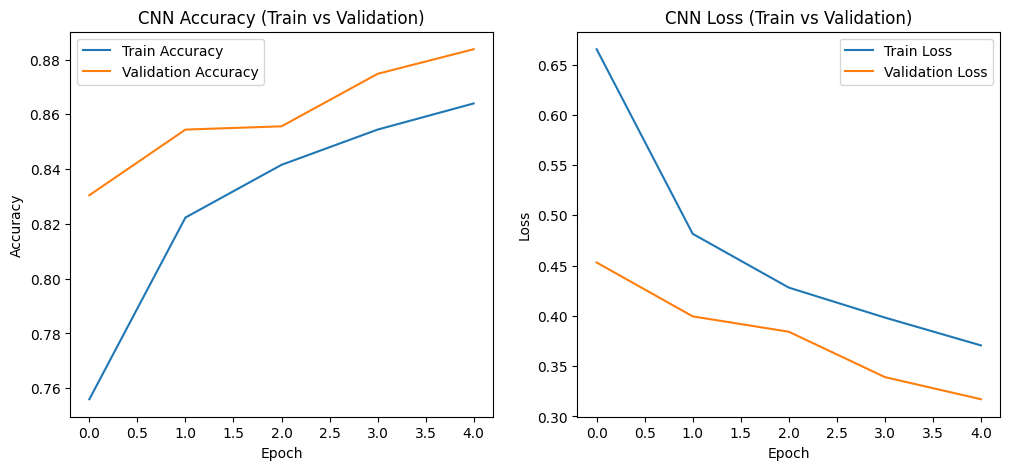

In [42]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

## Model 3

In [43]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
     layers.RandomRotation(0.05),
     layers.RandomZoom(0.05),
     #layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
#early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    #monitor="val_loss",
    #patience=5,
    #restore_best_weights=True
#)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_fashion = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    # Optional dropout
     #layers.Dropout(0.2),

    layers.Dense(10, activation="softmax")       # 10 Fashion MNIST classes
])

# Compile model
cnn_aug_fashion.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_fashion.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=5,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_fashion.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.7980 - loss: 0.5523 - val_accuracy: 0.8403 - val_loss: 0.4495
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8590 - loss: 0.3864 - val_accuracy: 0.8788 - val_loss: 0.3344
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.8752 - loss: 0.3379 - val_accuracy: 0.8814 - val_loss: 0.3282
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.8860 - loss: 0.3087 - val_accuracy: 0.8988 - val_loss: 0.2883
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 144s 77ms/step - accuracy: 0.8929 - loss: 0.2901 - val_accuracy: 0.8932 - val_loss: 0.2852
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8914 - loss: 0.3073
Augmented CNN test accuracy: 0.8914


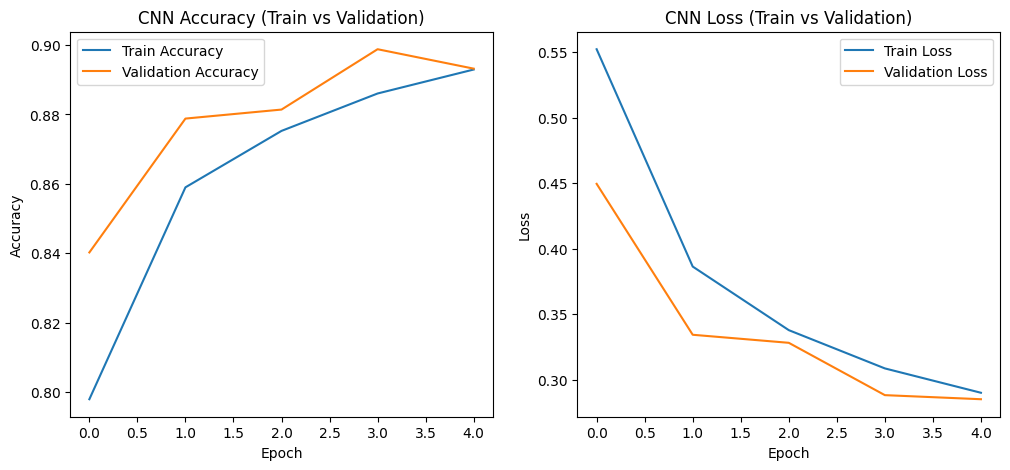

In [44]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

In [46]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


## Tuning with Optuna

In [ ]:

import optuna


train_ds_fast = train_ds_padded.take(300)
val_ds_fast = val_ds_padded.take(80)

train_ds_fast = train_ds_fast.cache().prefetch(tf.data.AUTOTUNE)
val_ds_fast = val_ds_fast.cache().prefetch(tf.data.AUTOTUNE)

def objective(trial):

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    filters_1 = trial.suggest_categorical("filters_1", [32, 64])
    filters_2 = trial.suggest_categorical("filters_2", [64, 128])
    dense_units = trial.suggest_categorical("dense_units", [64, 128])
    learning_rate = trial.suggest_categorical("learning_rate", [0.001, 0.0005])

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(filters_1, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters_2, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds_fast,
        validation_data=val_ds_fast,
        epochs=5,
        callbacks=[early_stopping],
        verbose=0
    )

    return max(history.history["val_accuracy"])


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=8)

print("Best validation accuracy:", study.best_value)
print("Best hyperparameters:")
print(study.best_params)

[I 2026-05-28 10:48:42,767] A new study created in memory with name: no-name-217877cd-6973-44c9-b0a9-269331e22ba7
[I 2026-05-28 10:49:48,899] Trial 0 finished with value: 0.872265636920929 and parameters: {'filters_1': 64, 'filters_2': 128, 'dense_units': 64, 'learning_rate': 0.0005}. Best is trial 0 with value: 0.872265636920929.
[I 2026-05-28 10:50:32,561] Trial 1 finished with value: 0.866406261920929 and parameters: {'filters_1': 64, 'filters_2': 64, 'dense_units': 64, 'learning_rate': 0.0005}. Best is trial 0 with value: 0.872265636920929.
[I 2026-05-28 10:51:20,558] Trial 2 finished with value: 0.8773437738418579 and parameters: {'filters_1': 64, 'filters_2': 64, 'dense_units': 128, 'learning_rate': 0.001}. Best is trial 2 with value: 0.8773437738418579.
[I 2026-05-28 10:52:17,639] Trial 3 finished with value: 0.860546886920929 and parameters: {'filters_1': 64, 'filters_2': 64, 'dense_units': 128, 'learning_rate': 0.0005}. Best is trial 2 with value: 0.8773437738418579.
[I 2026-0

Best validation accuracy: 0.8773437738418579
Best hyperparameters:
{'filters_1': 64, 'filters_2': 64, 'dense_units': 128, 'learning_rate': 0.001}


In [48]:
# Evaluate best model on held-out test set
test_loss, test_acc = cnn_fashion.evaluate(test_ds_padded)

print(f"Final CNN Test Loss: {test_loss:.4f}")
print(f"Final CNN Test Accuracy: {test_acc:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9131 - loss: 0.2473
Final CNN Test Loss: 0.2473
Final CNN Test Accuracy: 0.9131


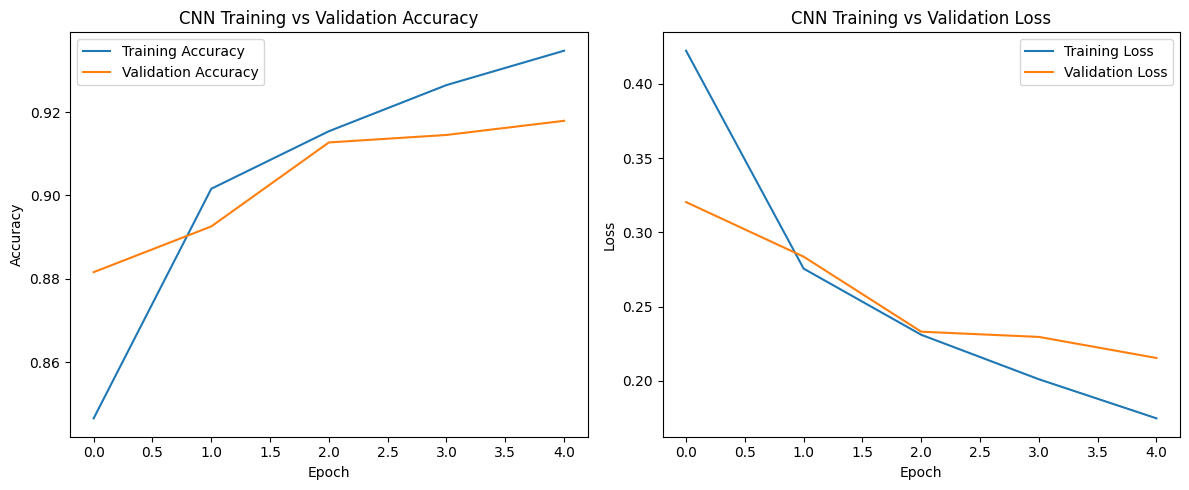

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Personal Workflow

After evaluating my final best model on a held out test set, I got an accuracy of 0.9132 with a test loss of 0.2473. I tested three CNN models using a guiding template to add or remove some features to test their relevance and importance. I made a CNN model with early stopping no data augmentation, and augmented CNN with dropout, and another CNN with fewer augmentation choices. The baseline cnn with only stopping performed the best overall, and this ca suggest that the images did not need heavy augementation to differentiate the distinct classes. Adding rotation, flips, zooming, and translations and dropout made the model more reduce performance because some transformations may have changed some of the clothing features. I noticed overfitting when the training accuracy improved faster than the validation accuracy or when validation loss stopped improving when the loss continued to decreased. Early stopping helped reduce this by putting in the best model weights. I lastly used Optuna to experiment with hyperparameters such as filter sizes, dense units, dropout, and learning rate. 

In the future, my workflow for building CNN models would be to start with a simple baseline model first, check the training and validation curves, and then add augmentation only if overfitting happens after implementing early stopping. I would prioritize validation accuracy, validation loss, and test-set performance over making the model more complex. More layers, augmentation, or tuning don't always guarantee better results and the best model is the one that generalizes well while staying somewhat simple. 